# Phase 3b — FinBERT Ablation (v2.4.1 recipe, matched 2017+ window)

**Designed for NYU Torch HPC Jupyter kernel (L40S GPU, 2 cores, 12h).** Drop-in port of the locked v2.4.1 recipe (see `phase1_v2_4_1_classification.ipynb`) — same loaders, models, training loop, Optuna search, MC-dropout inference, reproducibility appendix. Only differences:

1. **Paths point to `/scratch/np3129/AI_ML_Quants_VIP/`** (no Drive mount).
2. **Window clipped to 2017-01-02+** so baseline (B0) and +FinBERT (B1) share an identical date range — isolates *modality lift* from *less data*.
3. **Six runs:** {B0, B1} × {BiGRU, BiRNN+SelfAttn, BiRNN+Skip}. ARX is logistic-only and not part of the modality story; skipped here.
4. **`cv_deep` refactored** to take `(X_seq, y, splits, N_FEATURES)` as args instead of globals, so the same function runs on both B0 and B1 datasets.

## Pre-flight (run once, outside the notebook)

The FinBERT daily features CSV is produced by `phase3a_finbert_pull_and_features.ipynb` and saved to Drive. Copy it onto HPC before running:

```bash
# from the laptop, after downloading from Drive:
scp finbert_wheat_sentiment_daily.csv \
    dtn:/scratch/np3129/AI_ML_Quants_VIP/alternative_data/processed/
```

Cell 3 asserts the file exists and fails fast if not.

## Runtime estimate

Each `cv_deep` call = 50 Optuna trials × 5 folds × 1 train (with 60+5 epochs each, tiny models). On Colab T4 the v2.4.1 notebook runs all 4 models in ~1.5 h. On L40S we expect each cv_deep call ≈ 5–10 min, so 6 runs ≈ 30–60 min compute. Comfortably inside the 12 h budget.

## 1. Imports + determinism (matches v2.4.1 cell 2 verbatim)

In [1]:
!pip install -q optuna

In [2]:
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

from abc import ABC, abstractmethod
from pathlib import Path
import json, random, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, f1_score,
                             balanced_accuracy_score)
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import warnings; warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

def set_all_seeds(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)
print('Device:', DEVICE, '  Seed:', SEED, '  cudnn.deterministic:', torch.backends.cudnn.deterministic)

Device: cuda   Seed: 42   cudnn.deterministic: True


## 2. HPC paths

Repo root = `/scratch/np3129/AI_ML_Quants_VIP/`. Wheat + FRED data sit under `Quants data/Quants /` (mirrors the Drive structure thanks to the git push/pull workflow). FinBERT daily features sit under `alternative_data/processed/`.

In [3]:
REPO = Path('/scratch/np3129/AI_ML_Quants_VIP')
BASE = REPO / 'Quants data' / 'Quants '   # trailing space matches Drive folder name
WHEAT_18 = BASE / 'Investing.com' / 'US Wheat Futures Historical Data_2018.csv'
WHEAT_25 = BASE / 'Investing.com' / 'US Wheat Futures Historical Data_2025.csv'
FRED     = BASE / 'FredMD_Dataset' / '2025-10-MD.csv'
FINBERT  = REPO / 'alternative_data' / 'processed' / 'finbert_wheat_sentiment_daily.csv'
OUT_DIR  = REPO / 'results' / 'phase3_finbert'
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [WHEAT_18, WHEAT_25, FRED, FINBERT]:
    assert p.exists(), f'Missing input: {p}'
print('All inputs present. OUT_DIR =', OUT_DIR)

All inputs present. OUT_DIR = /scratch/np3129/AI_ML_Quants_VIP/results/phase3_finbert


## 3. Load wheat close (matches v2.4.1 cell 8 verbatim)

In [4]:
def load_close(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df['Price'] = df['Price'].astype(str).str.replace(',', '', regex=False).astype(float)
    return df['Price']

price = (pd.concat([load_close(WHEAT_18), load_close(WHEAT_25)])
         .pipe(lambda s: s[~s.index.duplicated(keep='last')])
         .sort_index())
price.name = 'Close'
print('Close price series:', price.shape, price.index.min().date(), '..', price.index.max().date())

Close price series: (6864,) 1999-08-01 .. 2025-12-12


## 4. Load FRED-MD — 31 TA variables, t-codes, 1-month publication lag, ffill (matches v2.4.1 cell 10 verbatim)

In [5]:
FEATURES_31 = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]
assert len(FEATURES_31) == 31

def apply_tcode(series, t):
    s = series.astype(float)
    if t == 1:   return s
    if t == 2:   return s.diff()
    if t == 3:   return s.diff().diff()
    if t == 4:   return np.log(s.clip(lower=1e-10))
    if t == 5:   return np.log(s.clip(lower=1e-10)).diff()
    if t == 6:   return np.log(s.clip(lower=1e-10)).diff().diff()
    if t == 7:   return (s / s.shift(1) - 1).diff()
    return s

tcodes_row = pd.read_csv(FRED, nrows=1)
fred_raw = pd.read_csv(FRED, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()
missing = [c for c in FEATURES_31 if c not in fred_raw.columns]
assert not missing, f'Missing FRED columns: {missing}'
tcodes = {c: int(tcodes_row[c].iloc[0]) for c in FEATURES_31}

fred_trans = pd.DataFrame({c: apply_tcode(fred_raw[c], tcodes[c]) for c in FEATURES_31})
fred_trans = fred_trans.replace([np.inf, -np.inf], np.nan).dropna()
fred_trans.index = fred_trans.index + pd.DateOffset(months=1)  # 1-month publication lag

daily_index = pd.date_range(fred_trans.index.min(), price.index.max(), freq='D')
fred_daily = fred_trans.reindex(daily_index).ffill()
print('FRED daily (forward-filled):', fred_daily.shape)

FRED daily (forward-filled): (17454, 31)


## 5. Load FinBERT daily features

Three columns from `phase3a_finbert_pull_and_features.ipynb`: `news_sentiment_mean`, `news_count`, `news_negative_tail_mean`. The 1-day publication lag is **already applied inside that notebook** (line 118 of `docs/phase3_progress_log.md`), so we do not lag again here.

In [6]:
finbert = pd.read_csv(FINBERT)
date_col = 'date' if 'date' in finbert.columns else finbert.columns[0]
finbert[date_col] = pd.to_datetime(finbert[date_col])
finbert = finbert.set_index(date_col).sort_index()
FINBERT_COLS = ['news_sentiment_mean', 'news_count', 'news_negative_tail_mean']
missing_fb = [c for c in FINBERT_COLS if c not in finbert.columns]
assert not missing_fb, f'Missing FinBERT columns: {missing_fb}; have {list(finbert.columns)}'
finbert = finbert[FINBERT_COLS].astype(np.float32)
# Forward-fill across calendar days so trading days that fall on weekends/holidays
# inherit the most recent published-news state. news_count NaNs treated as 0 first.
fb_daily_idx = pd.date_range(finbert.index.min(), price.index.max(), freq='D')
finbert_daily = finbert.reindex(fb_daily_idx)
finbert_daily['news_count'] = finbert_daily['news_count'].fillna(0.0)
finbert_daily[['news_sentiment_mean', 'news_negative_tail_mean']] = (
    finbert_daily[['news_sentiment_mean', 'news_negative_tail_mean']].fillna(0.0)
)
print('FinBERT daily:', finbert_daily.shape, finbert_daily.index.min().date(), '..', finbert_daily.index.max().date())
print(finbert_daily.describe().round(3))

FinBERT daily: (3267, 3) 2017-01-02 .. 2025-12-12
       news_sentiment_mean  news_count  news_negative_tail_mean
count             3267.000    3267.000                 3267.000
mean                -0.063      21.067                   -0.718
std                  0.208      12.352                    0.253
min                 -0.955       0.000                   -0.964
25%                 -0.179      11.000                   -0.906
50%                 -0.057      21.000                   -0.803
75%                  0.059      30.000                   -0.610
max                  0.860      77.000                    0.820


## 6. Build datasets B0 (33 channels) and B1 (36 channels), both clipped to 2017-01-02+

Same 30-day rolling-window construction as v2.4.1 cell 12, parameterised on whether to append the 3 FinBERT channels at each timestep. Both datasets share the **identical date range** so the comparison is matched-window.

In [7]:
LOOKBACK = 30
WINDOW_START = '2017-01-02'

def build_dataset(use_finbert: bool):
    if use_finbert:
        df = pd.concat([price, fred_daily, finbert_daily], axis=1, join='inner').dropna()
    else:
        df = pd.concat([price, fred_daily], axis=1, join='inner').dropna()
    df = df.sort_index().loc[WINDOW_START:]
    closes = df['Close'].values.astype(np.float64)
    log_rets = np.concatenate([[0.0], np.diff(np.log(np.clip(closes, 1e-9, None)))])
    macros = df[FEATURES_31].values.astype(np.float32)
    fb = df[FINBERT_COLS].values.astype(np.float32) if use_finbert else None
    dates = df.index

    X_list, y_list, idx_list = [], [], []
    for t in range(LOOKBACK, len(df)):
        price_window = np.stack([closes[t-LOOKBACK:t], log_rets[t-LOOKBACK:t]], axis=1)  # (30,2)
        macro_window = macros[t-LOOKBACK:t]                                              # (30,31)
        chunks = [price_window, macro_window]
        if use_finbert:
            chunks.append(fb[t-LOOKBACK:t])                                              # (30,3)
        step = np.concatenate(chunks, axis=1).astype(np.float32)
        X_list.append(step)
        y_list.append(1 if closes[t] > closes[t-1] else 0)
        idx_list.append(dates[t])

    X_seq = np.stack(X_list)
    y     = np.array(y_list, dtype=np.int64)
    idx   = pd.DatetimeIndex(idx_list)
    return X_seq, y, idx, X_seq.shape[-1]

X_B0, y_B0, idx_B0, NF_B0 = build_dataset(use_finbert=False)
X_B1, y_B1, idx_B1, NF_B1 = build_dataset(use_finbert=True)

print(f'B0 baseline:  X={X_B0.shape}  y_up={y_B0.mean():.4f}  N_FEATURES={NF_B0}  dates {idx_B0.min().date()}..{idx_B0.max().date()}')
print(f'B1 +FinBERT:  X={X_B1.shape}  y_up={y_B1.mean():.4f}  N_FEATURES={NF_B1}  dates {idx_B1.min().date()}..{idx_B1.max().date()}')

assert NF_B0 == 33 and NF_B1 == 36, 'Channel counts must be 33 and 36 — matches design in phase3_progress_log.md'
assert np.array_equal(idx_B0.values, idx_B1.values), 'B0 and B1 must share identical date axis (matched-window)'
assert np.array_equal(y_B0, y_B1), 'Targets must align between B0 and B1'

B0 baseline:  X=(2262, 30, 33)  y_up=0.4717  N_FEATURES=33  dates 2017-02-15..2025-12-12
B1 +FinBERT:  X=(2262, 30, 36)  y_up=0.4717  N_FEATURES=36  dates 2017-02-15..2025-12-12


## 7. TimeSeriesSplit + per-fold scaler (matches v2.4.1 cell 14 verbatim)

In [8]:
tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(np.arange(len(y_B0))))
for i, (tr, va) in enumerate(splits):
    print(f'Fold {i+1}: train n={len(tr):4d}  [{idx_B0[tr[0]].date()}..{idx_B0[tr[-1]].date()}]  '
          f'val n={len(va):4d}  [{idx_B0[va[0]].date()}..{idx_B0[va[-1]].date()}]  '
          f'val up={y_B0[va].mean():.3f}')

def scale_fold_seq(X_tr, X_va):
    N_tr, T, F = X_tr.shape
    sc = StandardScaler().fit(X_tr.reshape(-1, F))
    X_tr_s = sc.transform(X_tr.reshape(-1, F)).reshape(N_tr, T, F).astype(np.float32)
    X_va_s = sc.transform(X_va.reshape(-1, F)).reshape(X_va.shape[0], T, F).astype(np.float32)
    return X_tr_s, X_va_s

Fold 1: train n= 377  [2017-02-15..2018-08-09]  val n= 377  [2018-08-10..2020-01-22]  val up=0.485
Fold 2: train n= 754  [2017-02-15..2020-01-22]  val n= 377  [2020-01-23..2021-07-07]  val up=0.477
Fold 3: train n=1131  [2017-02-15..2021-07-07]  val n= 377  [2021-07-08..2022-12-22]  val up=0.469
Fold 4: train n=1508  [2017-02-15..2022-12-22]  val n= 377  [2022-12-23..2024-06-20]  val up=0.464
Fold 5: train n=1885  [2017-02-15..2024-06-20]  val n= 377  [2024-06-21..2025-12-12]  val up=0.462


## 8. Training loop + helpers (matches v2.4.1 cell 16 verbatim)

In [9]:
def orth_init_rnn(rnn):
    for name, p in rnn.named_parameters():
        if 'weight_hh' in name: nn.init.orthogonal_(p)
        elif 'weight_ih' in name: nn.init.kaiming_normal_(p)
        elif 'bias' in name: nn.init.zeros_(p)

def best_threshold(y_true, y_prob, metric='balanced_accuracy'):
    grid = np.linspace(0.30, 0.70, 41)
    best_t, best_s = 0.5, -1.0
    for t in grid:
        pred = (y_prob > t).astype(int)
        s = balanced_accuracy_score(y_true, pred) if metric == 'balanced_accuracy' \
            else accuracy_score(y_true, pred)
        if s > best_s: best_s, best_t = s, float(t)
    return best_t

def _swa_average(state_dicts):
    out = {}
    for k in state_dicts[0]:
        stacked = torch.stack([sd[k].float() for sd in state_dicts], dim=0)
        out[k] = stacked.mean(dim=0).to(state_dicts[0][k].dtype)
    return out

def _mc_dropout_forward(model, X_t, mc_passes=5, base_seed=0):
    if mc_passes <= 1:
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(model(X_t).squeeze(-1)).cpu().numpy()
    preds = []
    for i in range(mc_passes):
        torch.manual_seed(base_seed + i)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(base_seed + i)
        model.train()
        with torch.no_grad():
            preds.append(torch.sigmoid(model(X_t).squeeze(-1)).cpu().numpy())
    model.eval()
    return np.mean(preds, axis=0)

def train_torch_classifier(model, X_tr, y_tr, X_va, y_va,
                           epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4,
                           patience=8, clip=1.0,
                           swa_k=5, swa_lr_factor=0.5, mc_passes=5, dl_seed=0):
    model = model.to(DEVICE)
    pw = torch.tensor([(1 - y_tr.mean()) / max(y_tr.mean(), 1e-6)], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    g = torch.Generator(); g.manual_seed(dl_seed)
    ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr.astype(np.float32)))
    ld = DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)
    X_va_t = torch.from_numpy(X_va).to(DEVICE)
    X_tr_t = torch.from_numpy(X_tr).to(DEVICE)

    best_auc, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logit = model(xb).squeeze(-1)
            loss = loss_fn(logit, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            p_va = torch.sigmoid(model(X_va_t).squeeze(-1)).cpu().numpy()
        try: auc = roc_auc_score(y_va, p_va)
        except ValueError: auc = 0.5
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    if swa_k and swa_k > 0:
        swa_opt = torch.optim.AdamW(model.parameters(),
                                    lr=lr * swa_lr_factor, weight_decay=weight_decay)
        g2 = torch.Generator(); g2.manual_seed(dl_seed + 10_000)
        ld2 = DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g2)
        swa_buf = []
        for ep in range(swa_k):
            model.train()
            for xb, yb in ld2:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                swa_opt.zero_grad()
                logit = model(xb).squeeze(-1)
                loss = loss_fn(logit, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip)
                swa_opt.step()
            swa_buf.append({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
        swa_state = _swa_average(swa_buf)
        model.load_state_dict({k: v.to(DEVICE) for k, v in swa_state.items()})
        model.eval()
        with torch.no_grad():
            p_va_swa = torch.sigmoid(model(X_va_t).squeeze(-1)).cpu().numpy()
        try: swa_auc = roc_auc_score(y_va, p_va_swa)
        except ValueError: swa_auc = 0.5
        if swa_auc < best_auc:
            model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    p_tr = _mc_dropout_forward(model, X_tr_t, mc_passes=mc_passes, base_seed=dl_seed * 1000)
    p_va = _mc_dropout_forward(model, X_va_t, mc_passes=mc_passes, base_seed=dl_seed * 1000 + 1)
    try: final_auc = roc_auc_score(y_va, p_va)
    except ValueError: final_auc = 0.5
    return model, p_tr, p_va, final_auc

## 9. Metrics reporter (matches v2.4.1 cell 18 verbatim, plot off by default to keep the notebook compact)

In [10]:
def report_metrics(name, y_true, y_prob, y_pred, show_plot=False):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try: auc = roc_auc_score(y_true, y_prob)
    except ValueError: auc = float('nan')
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'AUC      : {auc:.4f}')
    print(f'F1       : {f1:.4f}')
    print(f'Precision [down, up] : [{prec[0]:.4f}, {prec[1]:.4f}]')
    print(f'Recall    [down, up] : [{rec[0]:.4f}, {rec[1]:.4f}]')
    print(f'Confusion matrix:\n{cm}')
    return {'name': name, 'acc': acc, 'auc': auc, 'f1': f1,
            'prec_dn': prec[0], 'prec_up': prec[1],
            'rec_dn': rec[0],   'rec_up': rec[1]}

## 10. Model classes (BiGRU, BiRNN+SelfAttn, BiRNN+Skip — verbatim from v2.4.1)

In [11]:
class BaseForecastModel(ABC):
    def __init__(self, task_type, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters
    @abstractmethod
    def fit(self, X_train, y_train): pass
    @abstractmethod
    def predict(self, X): pass
    @abstractmethod
    def evaluate(self, X_test, y_test): pass
    @abstractmethod
    def save(self, fp): pass
    @abstractmethod
    def load(self, fp): pass


class BiGRUClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3, pool='mean'):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout, pool=pool)
        self.pool = pool
        self.rnn = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True,
                          bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        orth_init_rnn(self.rnn)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout),
                                  nn.Linear(2*hidden, 1))
    def _pool(self, out):
        if self.pool == 'mean': return out.mean(dim=1)
        if self.pool == 'max':  return out.max(dim=1).values
        return out[:, -1, :]
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(self._pool(out))
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1))
                    .cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))


class BiRNNSelfAttnClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3, n_heads=2):
        nn.Module.__init__(self)
        d = 2 * hidden
        while n_heads > 1 and d % n_heads != 0:
            n_heads -= 1
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout, n_heads=n_heads)
        self.rnn = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True,
                          bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        orth_init_rnn(self.rnn)
        self.attn = nn.MultiheadAttention(d, num_heads=n_heads, dropout=dropout, batch_first=True)
        self.ln_attn = nn.LayerNorm(d)
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Dropout(dropout), nn.Linear(d, 1))
    def forward(self, x):
        out, _ = self.rnn(x)
        T = out.size(1)
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        attn_out, _ = self.attn(out, out, out, attn_mask=mask, need_weights=False)
        h = self.ln_attn(out + attn_out)
        ctx = h[:, -1, :]
        return self.head(ctx)
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1))
                    .cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))


class BiRNNSkipClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3, pool='mean'):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout, pool=pool)
        self.pool = pool
        self.pre_ln = nn.LayerNorm(n_features)
        self.rnn1 = nn.GRU(n_features, hidden, batch_first=True, bidirectional=True)
        orth_init_rnn(self.rnn1)
        self.skip_proj = nn.Linear(n_features, 2*hidden)
        self.drop = nn.Dropout(dropout)
        self.use_second = (layers == 2)
        if self.use_second:
            self.mid_ln = nn.LayerNorm(2*hidden)
            self.rnn2 = nn.GRU(2*hidden, hidden, batch_first=True, bidirectional=True)
            orth_init_rnn(self.rnn2)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout),
                                  nn.Linear(2*hidden, 1))
    def _pool(self, out):
        if self.pool == 'mean': return out.mean(dim=1)
        if self.pool == 'max':  return out.max(dim=1).values
        return out[:, -1, :]
    def forward(self, x):
        x_n = self.pre_ln(x)
        r1, _ = self.rnn1(x_n)
        r1 = self.drop(r1 + self.skip_proj(x_n))
        if self.use_second:
            r2, _ = self.rnn2(self.mid_ln(r1))
            r1 = r2 + r1
        return self.head(self._pool(r1))
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1))
                    .cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))

## 11. Optuna CV — refactored to take dataset as argument

Same search space, sampler, pruner, training recipe as v2.4.1 cell 28. Only change: `(X_seq, y, splits, n_features)` are passed in instead of read from globals. Lets us call once per (config, model) pair.

In [12]:
def suggest_hparams(trial, with_pool=False, with_heads=False):
    hp = {
        'hidden':       trial.suggest_categorical('hidden', [16, 24, 32, 48]),
        'layers':       trial.suggest_categorical('layers', [1, 2]),
        'dropout':      trial.suggest_float('dropout', 0.2, 0.6),
        'lr':           trial.suggest_float('lr', 1e-4, 3e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
        'batch_size':   trial.suggest_categorical('batch_size', [32, 64, 128]),
    }
    if with_pool:
        hp['pool'] = trial.suggest_categorical('pool', ['last', 'mean', 'max'])
    if with_heads:
        hp['n_heads'] = trial.suggest_categorical('n_heads', [1, 2, 4])
    return hp

def cv_deep(model_cls, X_seq, y, splits, n_features,
            n_trials=50, name='model', tune_pool=False, tune_heads=False):
    def objective(trial):
        set_all_seeds(SEED)
        hp = suggest_hparams(trial, with_pool=tune_pool, with_heads=tune_heads)
        fold_aucs = []
        for i, (tr, va) in enumerate(splits):
            X_tr, X_va = scale_fold_seq(X_seq[tr], X_seq[va])
            kwargs = dict(n_features=n_features, hidden=hp['hidden'],
                          layers=hp['layers'], dropout=hp['dropout'])
            if tune_pool:  kwargs['pool']    = hp['pool']
            if tune_heads: kwargs['n_heads'] = hp['n_heads']
            set_all_seeds(SEED + i)
            model = model_cls(**kwargs)
            _, _, p_va, _ = train_torch_classifier(
                model, X_tr, y[tr], X_va, y[va],
                epochs=60, batch_size=hp['batch_size'], lr=hp['lr'],
                weight_decay=hp['weight_decay'], patience=8, clip=1.0,
                swa_k=5, dl_seed=SEED + i)
            try: auc = roc_auc_score(y[va], p_va)
            except ValueError: auc = 0.5
            fold_aucs.append(auc)
            trial.report(auc, i)
            if trial.should_prune(): raise optuna.TrialPruned()
            del model; torch.cuda.empty_cache()
        return float(np.mean(fold_aucs))

    study = optuna.create_study(direction='maximize',
                                sampler=TPESampler(seed=SEED),
                                pruner=MedianPruner(n_warmup_steps=2))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'[{name}] best val AUC = {study.best_value:.4f}   best params = {study.best_params}')
    hp = study.best_params

    per_fold, fold_thr = [], []
    all_y, all_p, all_pred = [], [], []
    for fold_i, (tr, va) in enumerate(splits):
        X_tr, X_va = scale_fold_seq(X_seq[tr], X_seq[va])
        kwargs = dict(n_features=n_features, hidden=hp['hidden'],
                      layers=hp['layers'], dropout=hp['dropout'])
        if tune_pool:  kwargs['pool']    = hp['pool']
        if tune_heads: kwargs['n_heads'] = hp['n_heads']
        set_all_seeds(SEED + fold_i)
        model = model_cls(**kwargs)
        _, p_tr, p_va, _ = train_torch_classifier(
            model, X_tr, y[tr], X_va, y[va],
            epochs=60, batch_size=hp['batch_size'], lr=hp['lr'],
            weight_decay=hp['weight_decay'], patience=8, clip=1.0,
            swa_k=5, dl_seed=SEED + fold_i)
        thr = best_threshold(y[tr], p_tr)
        pred_va = (p_va > thr).astype(int)
        acc = accuracy_score(y[va], pred_va)
        per_fold.append(acc); fold_thr.append(thr)
        all_y.append(y[va]); all_p.append(p_va); all_pred.append(pred_va)
        print(f'[{name}] fold {fold_i+1}: thr={thr:.3f}  acc={acc:.4f}')
        del model; torch.cuda.empty_cache()

    print(f'[{name}] per-fold thr={[round(t,3) for t in fold_thr]}  '
          f'acc={[round(a,4) for a in per_fold]}  mean={np.mean(per_fold):.4f}')
    trials_df = study.trials_dataframe()
    return (np.concatenate(all_y), np.concatenate(all_p), np.concatenate(all_pred),
            {'best_auc': study.best_value, 'best_params': hp,
             'fold_accs': per_fold, 'fold_thr': fold_thr,
             'trials_df': trials_df})

## 12. Run six cells — {B0, B1} × {BiGRU, BiRNN+SelfAttn, BiRNN+Skip}

Each call is fully self-contained — re-running any one cell does not affect the others. Wall-clock per call ≈ 5–10 min on L40S (50 trials × 5 folds, tiny models).

In [13]:
# ---- B0 baseline-2017+, BiGRU ----
y_B0_bg, p_B0_bg, pred_B0_bg, info_B0_bg = cv_deep(
    BiGRUClassifier, X_B0, y_B0, splits, NF_B0,
    n_trials=50, name='B0/BiGRU', tune_pool=True)
m_B0_bg = report_metrics('B0 BiGRU (baseline-2017+)', y_B0_bg, p_B0_bg, pred_B0_bg)

  0%|          | 0/50 [00:00<?, ?it/s]

[B0/BiGRU] best val AUC = 0.5422   best params = {'hidden': 32, 'layers': 2, 'dropout': 0.20311640101497364, 'lr': 0.0013190506162616268, 'weight_decay': 2.5601546674484124e-05, 'batch_size': 32, 'pool': 'last'}
[B0/BiGRU] fold 1: thr=0.490  acc=0.5119
[B0/BiGRU] fold 2: thr=0.510  acc=0.5066
[B0/BiGRU] fold 3: thr=0.520  acc=0.5650
[B0/BiGRU] fold 4: thr=0.520  acc=0.4987
[B0/BiGRU] fold 5: thr=0.510  acc=0.5305
[B0/BiGRU] per-fold thr=[0.49, 0.51, 0.52, 0.52, 0.51]  acc=[0.5119, 0.5066, 0.565, 0.4987, 0.5305]  mean=0.5225

=== B0 BiGRU (baseline-2017+) ===
Accuracy : 0.5225
AUC      : 0.5334
F1       : 0.5303
Precision [down, up] : [0.5559, 0.4946]
Recall    [down, up] : [0.4789, 0.5714]
Confusion matrix:
[[477 519]
 [381 508]]


In [14]:
# ---- B0 baseline-2017+, BiRNN+SelfAttn ----
y_B0_at, p_B0_at, pred_B0_at, info_B0_at = cv_deep(
    BiRNNSelfAttnClassifier, X_B0, y_B0, splits, NF_B0,
    n_trials=50, name='B0/SelfAttn', tune_heads=True)
m_B0_at = report_metrics('B0 BiRNN+SelfAttn (baseline-2017+)', y_B0_at, p_B0_at, pred_B0_at)

  0%|          | 0/50 [00:00<?, ?it/s]

[B0/SelfAttn] best val AUC = 0.5304   best params = {'hidden': 48, 'layers': 1, 'dropout': 0.29950539918592195, 'lr': 0.002445402390043687, 'weight_decay': 0.0022060785459744356, 'batch_size': 32, 'n_heads': 1}
[B0/SelfAttn] fold 1: thr=0.520  acc=0.5119
[B0/SelfAttn] fold 2: thr=0.540  acc=0.4695
[B0/SelfAttn] fold 3: thr=0.470  acc=0.5225
[B0/SelfAttn] fold 4: thr=0.530  acc=0.5305
[B0/SelfAttn] fold 5: thr=0.480  acc=0.5252
[B0/SelfAttn] per-fold thr=[0.52, 0.54, 0.47, 0.53, 0.48]  acc=[0.5119, 0.4695, 0.5225, 0.5305, 0.5252]  mean=0.5119

=== B0 BiRNN+SelfAttn (baseline-2017+) ===
Accuracy : 0.5119
AUC      : 0.5177
F1       : 0.3548
Precision [down, up] : [0.5282, 0.4711]
Recall    [down, up] : [0.7149, 0.2846]
Confusion matrix:
[[712 284]
 [636 253]]


In [15]:
# ---- B0 baseline-2017+, BiRNN+Skip ----
y_B0_sk, p_B0_sk, pred_B0_sk, info_B0_sk = cv_deep(
    BiRNNSkipClassifier, X_B0, y_B0, splits, NF_B0,
    n_trials=50, name='B0/Skip', tune_pool=True)
m_B0_sk = report_metrics('B0 BiRNN+Skip (baseline-2017+)', y_B0_sk, p_B0_sk, pred_B0_sk)

  0%|          | 0/50 [00:00<?, ?it/s]

[B0/Skip] best val AUC = 0.5414   best params = {'hidden': 32, 'layers': 2, 'dropout': 0.20290616077889656, 'lr': 0.00018317407087208463, 'weight_decay': 0.0001532400377312049, 'batch_size': 64, 'pool': 'mean'}
[B0/Skip] fold 1: thr=0.510  acc=0.5279
[B0/Skip] fold 2: thr=0.500  acc=0.4987
[B0/Skip] fold 3: thr=0.430  acc=0.5199
[B0/Skip] fold 4: thr=0.500  acc=0.5332
[B0/Skip] fold 5: thr=0.500  acc=0.5464
[B0/Skip] per-fold thr=[0.51, 0.5, 0.43, 0.5, 0.5]  acc=[0.5279, 0.4987, 0.5199, 0.5332, 0.5464]  mean=0.5252

=== B0 BiRNN+Skip (baseline-2017+) ===
Accuracy : 0.5252
AUC      : 0.5371
F1       : 0.5031
Precision [down, up] : [0.5519, 0.4967]
Recall    [down, up] : [0.5392, 0.5096]
Confusion matrix:
[[537 459]
 [436 453]]


In [16]:
# ---- B1 +FinBERT, BiGRU ----
y_B1_bg, p_B1_bg, pred_B1_bg, info_B1_bg = cv_deep(
    BiGRUClassifier, X_B1, y_B1, splits, NF_B1,
    n_trials=50, name='B1/BiGRU', tune_pool=True)
m_B1_bg = report_metrics('B1 BiGRU (+FinBERT)', y_B1_bg, p_B1_bg, pred_B1_bg)

  0%|          | 0/50 [00:00<?, ?it/s]

[B1/BiGRU] best val AUC = 0.5536   best params = {'hidden': 32, 'layers': 2, 'dropout': 0.20462218032407992, 'lr': 0.0010079650599845158, 'weight_decay': 0.002178240795360726, 'batch_size': 32, 'pool': 'mean'}
[B1/BiGRU] fold 1: thr=0.450  acc=0.5385
[B1/BiGRU] fold 2: thr=0.490  acc=0.4934
[B1/BiGRU] fold 3: thr=0.470  acc=0.5570
[B1/BiGRU] fold 4: thr=0.510  acc=0.5650
[B1/BiGRU] fold 5: thr=0.550  acc=0.4695
[B1/BiGRU] per-fold thr=[0.45, 0.49, 0.47, 0.51, 0.55]  acc=[0.5385, 0.4934, 0.557, 0.565, 0.4695]  mean=0.5247

=== B1 BiGRU (+FinBERT) ===
Accuracy : 0.5247
AUC      : 0.5239
F1       : 0.5493
Precision [down, up] : [0.5636, 0.4968]
Recall    [down, up] : [0.4448, 0.6142]
Confusion matrix:
[[443 553]
 [343 546]]


In [17]:
# ---- B1 +FinBERT, BiRNN+SelfAttn ----
y_B1_at, p_B1_at, pred_B1_at, info_B1_at = cv_deep(
    BiRNNSelfAttnClassifier, X_B1, y_B1, splits, NF_B1,
    n_trials=50, name='B1/SelfAttn', tune_heads=True)
m_B1_at = report_metrics('B1 BiRNN+SelfAttn (+FinBERT)', y_B1_at, p_B1_at, pred_B1_at)

  0%|          | 0/50 [00:00<?, ?it/s]

[B1/SelfAttn] best val AUC = 0.5377   best params = {'hidden': 48, 'layers': 1, 'dropout': 0.3833174473972856, 'lr': 0.00016830308997680638, 'weight_decay': 0.004323703904774225, 'batch_size': 128, 'n_heads': 2}
[B1/SelfAttn] fold 1: thr=0.300  acc=0.4907
[B1/SelfAttn] fold 2: thr=0.520  acc=0.5040
[B1/SelfAttn] fold 3: thr=0.630  acc=0.5146
[B1/SelfAttn] fold 4: thr=0.600  acc=0.5358
[B1/SelfAttn] fold 5: thr=0.490  acc=0.5119
[B1/SelfAttn] per-fold thr=[0.3, 0.52, 0.63, 0.6, 0.49]  acc=[0.4907, 0.504, 0.5146, 0.5358, 0.5119]  mean=0.5114

=== B1 BiRNN+SelfAttn (+FinBERT) ===
Accuracy : 0.5114
AUC      : 0.5274
F1       : 0.4937
Precision [down, up] : [0.5393, 0.4828]
Recall    [down, up] : [0.5171, 0.5051]
Confusion matrix:
[[515 481]
 [440 449]]


In [18]:
# ---- B1 +FinBERT, BiRNN+Skip ----
y_B1_sk, p_B1_sk, pred_B1_sk, info_B1_sk = cv_deep(
    BiRNNSkipClassifier, X_B1, y_B1, splits, NF_B1,
    n_trials=50, name='B1/Skip', tune_pool=True)
m_B1_sk = report_metrics('B1 BiRNN+Skip (+FinBERT)', y_B1_sk, p_B1_sk, pred_B1_sk)

  0%|          | 0/50 [00:00<?, ?it/s]

[B1/Skip] best val AUC = 0.5431   best params = {'hidden': 24, 'layers': 2, 'dropout': 0.4153980067184068, 'lr': 0.0009150823223866664, 'weight_decay': 0.00027973028628205417, 'batch_size': 32, 'pool': 'mean'}
[B1/Skip] fold 1: thr=0.460  acc=0.5517
[B1/Skip] fold 2: thr=0.500  acc=0.5119
[B1/Skip] fold 3: thr=0.470  acc=0.5066
[B1/Skip] fold 4: thr=0.470  acc=0.4775
[B1/Skip] fold 5: thr=0.520  acc=0.5332
[B1/Skip] per-fold thr=[0.46, 0.5, 0.47, 0.47, 0.52]  acc=[0.5517, 0.5119, 0.5066, 0.4775, 0.5332]  mean=0.5162

=== B1 BiRNN+Skip (+FinBERT) ===
Accuracy : 0.5162
AUC      : 0.5223
F1       : 0.5215
Precision [down, up] : [0.5484, 0.4887]
Recall    [down, up] : [0.4779, 0.5591]
Confusion matrix:
[[476 520]
 [392 497]]


## 13. Comparison table — modality lift per model

         model  B0_acc  B1_acc  acc_lift  B0_auc  B1_auc  auc_lift
         BiGRU  0.5225  0.5247    0.0021  0.5334  0.5239   -0.0096
BiRNN+SelfAttn  0.5119  0.5114   -0.0005  0.5177  0.5274    0.0097
    BiRNN+Skip  0.5252  0.5162   -0.0090  0.5371  0.5223   -0.0148


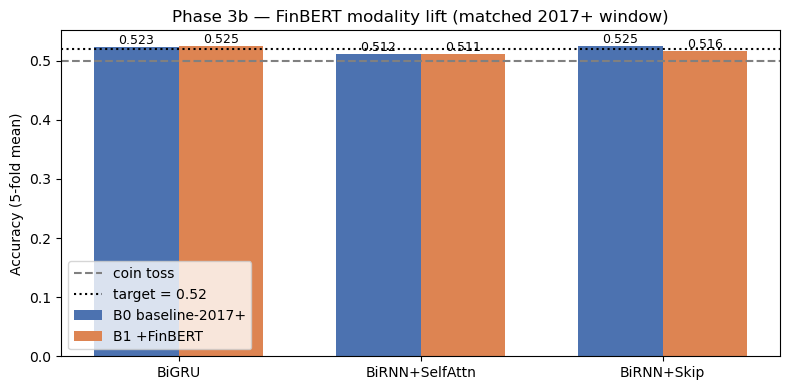

In [19]:
rows = []
for model_name, m0, m1 in [
    ('BiGRU',           m_B0_bg, m_B1_bg),
    ('BiRNN+SelfAttn',  m_B0_at, m_B1_at),
    ('BiRNN+Skip',      m_B0_sk, m_B1_sk),
]:
    rows.append({
        'model':       model_name,
        'B0_acc':      m0['acc'],   'B1_acc':      m1['acc'],
        'acc_lift':    m1['acc']  - m0['acc'],
        'B0_auc':      m0['auc'],   'B1_auc':      m1['auc'],
        'auc_lift':    m1['auc']  - m0['auc'],
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
summary.to_csv(OUT_DIR / 'phase3_finbert_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(summary)); w = 0.35
ax.bar(x - w/2, summary['B0_acc'], w, label='B0 baseline-2017+', color='#4C72B0')
ax.bar(x + w/2, summary['B1_acc'], w, label='B1 +FinBERT',       color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(summary['model'])
ax.axhline(0.5,  linestyle='--', color='gray',  label='coin toss')
ax.axhline(0.52, linestyle=':',  color='black', label='target = 0.52')
ax.set_ylabel('Accuracy (5-fold mean)')
ax.set_title('Phase 3b — FinBERT modality lift (matched 2017+ window)')
for i, (b0, b1) in enumerate(zip(summary['B0_acc'], summary['B1_acc'])):
    ax.text(i - w/2, b0 + 0.005, f'{b0:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, b1 + 0.005, f'{b1:.3f}', ha='center', fontsize=9)
ax.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / 'phase3_finbert_summary.png', dpi=150)
plt.show()

## 14. Save artifacts (predictions, fold accs, optuna trials, best-params)

In [20]:
fold_dates = np.concatenate([idx_B0.values[va] for _, va in splits])
preds_map = {
    'B0_bigru':       (y_B0_bg, p_B0_bg, pred_B0_bg),
    'B0_birnn_attn':  (y_B0_at, p_B0_at, pred_B0_at),
    'B0_birnn_skip':  (y_B0_sk, p_B0_sk, pred_B0_sk),
    'B1_bigru':       (y_B1_bg, p_B1_bg, pred_B1_bg),
    'B1_birnn_attn':  (y_B1_at, p_B1_at, pred_B1_at),
    'B1_birnn_skip':  (y_B1_sk, p_B1_sk, pred_B1_sk),
}
for name, (yt, pt, prt) in preds_map.items():
    pd.DataFrame({'date': fold_dates, 'y_true': yt, 'y_prob': pt, 'y_pred': prt}) \
      .to_csv(OUT_DIR / f'preds_{name}.csv', index=False)

fold_rows = []
info_map = {
    'B0_BiGRU':           info_B0_bg, 'B0_BiRNN+SelfAttn':  info_B0_at, 'B0_BiRNN+Skip':      info_B0_sk,
    'B1_BiGRU':           info_B1_bg, 'B1_BiRNN+SelfAttn':  info_B1_at, 'B1_BiRNN+Skip':      info_B1_sk,
}
for nm, info in info_map.items():
    for i, (a, t) in enumerate(zip(info['fold_accs'], info['fold_thr'])):
        fold_rows.append({'config_model': nm, 'fold': i+1, 'accuracy': a, 'threshold': t})
pd.DataFrame(fold_rows).to_csv(OUT_DIR / 'fold_accuracies.csv', index=False)

for nm, info in info_map.items():
    info['trials_df'].to_csv(OUT_DIR / f'optuna_trials_{nm.replace("+","_").replace("/","_")}.csv', index=False)

best_params = {nm: info['best_params'] for nm, info in info_map.items()}
with open(OUT_DIR / 'best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=str)

print('Saved artifacts to:', OUT_DIR)
print(sorted(os.listdir(OUT_DIR)))

Saved artifacts to: /scratch/np3129/AI_ML_Quants_VIP/results/phase3_finbert
['best_params.json', 'fold_accuracies.csv', 'optuna_trials_B0_BiGRU.csv', 'optuna_trials_B0_BiRNN_SelfAttn.csv', 'optuna_trials_B0_BiRNN_Skip.csv', 'optuna_trials_B1_BiGRU.csv', 'optuna_trials_B1_BiRNN_SelfAttn.csv', 'optuna_trials_B1_BiRNN_Skip.csv', 'phase3_finbert_summary.csv', 'phase3_finbert_summary.png', 'preds_B0_bigru.csv', 'preds_B0_birnn_attn.csv', 'preds_B0_birnn_skip.csv', 'preds_B1_bigru.csv', 'preds_B1_birnn_attn.csv', 'preds_B1_birnn_skip.csv']


## 15. Reproducibility check — re-run B1/BiGRU and assert byte-identical predictions

Same idea as the v2.4.1 reproducibility cell. We pick **one** representative cell (B1/BiGRU) rather than all six, because Optuna's sampler is the only stochastic component and a single retest is sufficient to demonstrate the recipe is deterministic. If this fails, all six runs are suspect.

In [21]:
y_B1_bg2, p_B1_bg2, pred_B1_bg2, info_B1_bg2 = cv_deep(
    BiGRUClassifier, X_B1, y_B1, splits, NF_B1,
    n_trials=50, name='B1/BiGRU (rerun)', tune_pool=True)

assert np.array_equal(pred_B1_bg, pred_B1_bg2), 'Predictions diverged on rerun — recipe is non-deterministic'
assert np.allclose(p_B1_bg, p_B1_bg2, atol=0, rtol=0), 'Probabilities diverged on rerun'
assert info_B1_bg['best_params'] == info_B1_bg2['best_params'], 'Optuna picked different best params on rerun'
print('Reproducibility OK — B1/BiGRU rerun produced byte-identical predictions and identical Optuna best params.')

  0%|          | 0/50 [00:00<?, ?it/s]

[B1/BiGRU (rerun)] best val AUC = 0.5536   best params = {'hidden': 32, 'layers': 2, 'dropout': 0.20462218032407992, 'lr': 0.0010079650599845158, 'weight_decay': 0.002178240795360726, 'batch_size': 32, 'pool': 'mean'}
[B1/BiGRU (rerun)] fold 1: thr=0.450  acc=0.5385
[B1/BiGRU (rerun)] fold 2: thr=0.490  acc=0.4934
[B1/BiGRU (rerun)] fold 3: thr=0.470  acc=0.5570
[B1/BiGRU (rerun)] fold 4: thr=0.510  acc=0.5650
[B1/BiGRU (rerun)] fold 5: thr=0.550  acc=0.4695
[B1/BiGRU (rerun)] per-fold thr=[0.45, 0.49, 0.47, 0.51, 0.55]  acc=[0.5385, 0.4934, 0.557, 0.565, 0.4695]  mean=0.5247
Reproducibility OK — B1/BiGRU rerun produced byte-identical predictions and identical Optuna best params.
